<a href="https://colab.research.google.com/github/shreyashyadav21/CBP/blob/main/burnout_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   employee_id            1000 non-null   int64  
 1   age                    1000 non-null   int64  
 2   years_experience       1000 non-null   int64  
 3   weekly_work_hours      1000 non-null   int64  
 4   meetings_per_week      1000 non-null   int64  
 5   emails_sent_per_day    1000 non-null   int64  
 6   projects_handled       1000 non-null   int64  
 7   remote_days_per_month  1000 non-null   int64  
 8   sleep_hours            1000 non-null   float64
 9   stress_level           1000 non-null   int64  
 10  exercise_hours_week    1000 non-null   float64
 11  sick_leaves_year       1000 non-null   int64  
 12  productivity_score     1000 non-null   int64  
 13  burnout_risk_score     1000 non-null   float64
dtypes: float64(3), int64(11)
memory usage: 109.5 KB


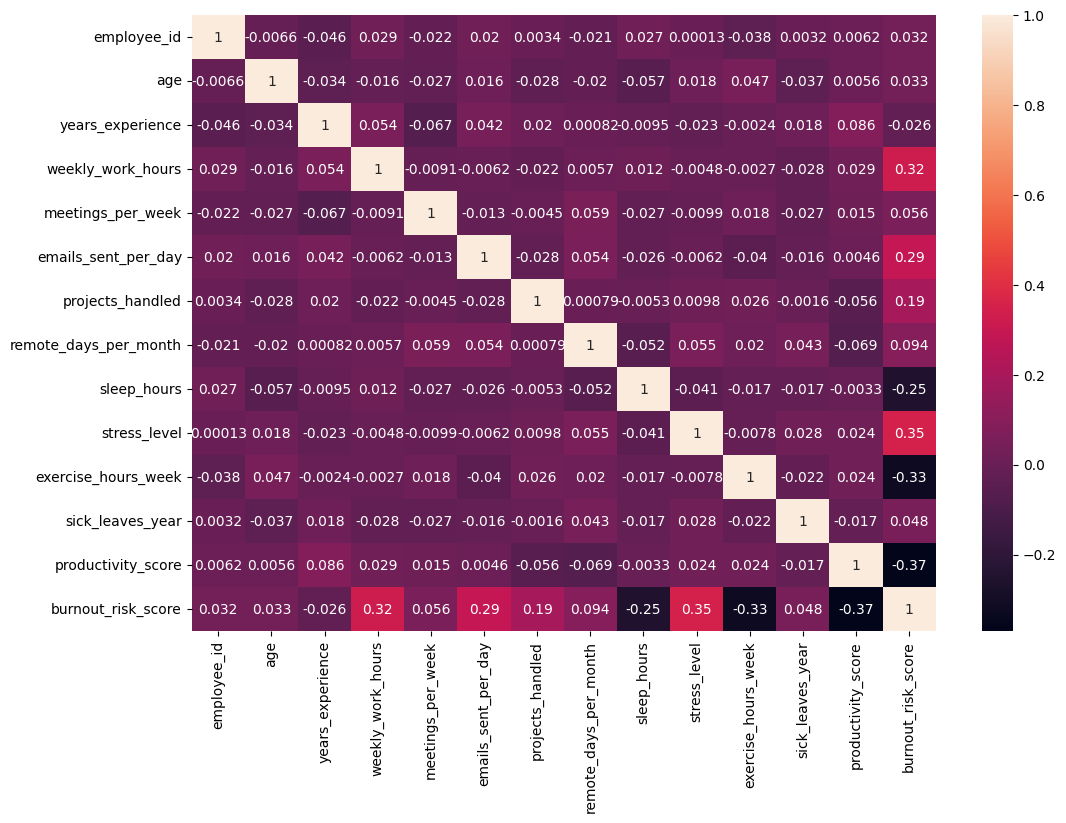

MAE = 4.649168905239442
MSE = 34.01820669220267
RMSE = 5.832512896874097
R2 = 0.6147494731514096
                  Feature  Coefficient
8            stress_level     1.104058
5        projects_handled     0.713070
2       weekly_work_hours     0.255077
10       sick_leaves_year     0.105400
3       meetings_per_week     0.088769
4     emails_sent_per_day     0.048611
6   remote_days_per_month     0.036438
0                     age     0.031162
1        years_experience    -0.004441
11     productivity_score    -0.209546
9     exercise_hours_week    -1.043501
7             sleep_hours    -1.582428


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
df = pd.read_csv("employee_burnout_dataset_1000_records.csv")

df.head()
df.info()

df.describe()

df.isnull().sum()
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True)
plt.show()
df.drop("employee_id", axis=1, inplace=True)

X = df.drop("burnout_risk_score", axis=1)

y = df["burnout_risk_score"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
model = LinearRegression()

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE =", mae)
print("MSE =", mse)
print("RMSE =", rmse)
print("R2 =", r2)
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print(coefficients.sort_values(
    by="Coefficient",
    ascending=False
))
